# 12. Coupled Thermal-Orbital Evolution

TidalPy calculates rates and leaves the integration to the user. This notebook couples TidalPy's thermal solve with its mutual-tide orbital and spin rates in one set of ordinary differential equations, and integrates them with CyRK for 5 Gyr.

The system is a hypothetical Earth-like planet (the bundled `earth_simple`) on an eccentric orbit about the Sun:

* semi-major axis 0.05 au and eccentricity 0.3;
* an initial spin 10 times its orbital motion;
* tides raised in both the planet and the Sun (`calc_pair_evolution`);
* a mantle with the Monteux et al. (2016) peridotite melting curves, which the bundled file gives it, and an Anderson-Gruneisen expansivity, so its melting and its adiabat follow the pressure (see [Partial-Melt Models](../../PartialMelt/partial_melt_models.md) and [Material EOS Models](../../Material/material_eos.md));
* tidal heat that warms the planet's layers through its tidal heat source.

The integration takes about a minute.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import CyRK
from tqdm import tqdm

from TidalPy.constants import au, year
from TidalPy.Structures import build_world
from TidalPy.Structures.system import System
from TidalPy.Utilities.logging import set_log_level

set_log_level("error")   # Every solve logs its molten regions at the info level
MYR = 1.0e6 * year       # [s]

## Building the System

The bundled `earth_simple` mantle already melts along the peridotite curves, which follow the pressure (`use_melting` and `use_pressure_melting`). Here its expansivity is also compressed ($\delta_{T0}$ = 5.5, $\kappa$ = 1.4), so its adiabat follows the pressure too. The planet pins a radial-solver tolerance of $10^{-8}$, tighter than the default $10^{-6}$. The implicit integrator differentiates the rates numerically, and the tighter tolerance keeps them smooth at the scale of its perturbations.

The bundled Sun has no spin, so it is given its sidereal rotation. `set_tidal_host(sun, planet)` makes the two a mutual pair, so the planet raises tides on the Sun as well. Each layer's `use_heating` lets the world's heat sources warm it: its radiogenic heat, and the tidal heat of the latest `calc_tides`.

In [2]:
config = build_world("earth_simple").get_config_dict()
config["name"] = "Planet"
config["radial_solver"] = {"rtol": 1.0e-8, "atol": 1.0e-12}   # Smooth rates for the implicit integrator
mantle_eos = config["layers"]["mantle"]["material"]["solid"]["eos"]
mantle_eos["anderson_gruneisen_parameter"] = 5.5                # The expansivity falls with compression
mantle_eos["anderson_gruneisen_exponent"] = 1.4

sun = build_world("sol")
sun.set_spin_frequency(2.0 * np.pi / (25.38 * 86400.0))   # Sidereal rotation [rad s-1]
planet = build_world(config)
for layer in planet:
    layer.use_heating = True                                 # Radiogenic and tidal heat enter each layer

A0 = 0.05 * au      # [m]
E0 = 0.3
SPIN_RATIO0 = 10.0  # Spin frequency / orbital motion

system = System("Exoplanet")
system.add_world(
    sun,
    is_star=True)
system.add_world(
    planet,
    tidal_host=sun,
    semi_major_axis=A0,
    eccentricity=E0)
system.set_tidal_host(sun, planet)   # The planet raises tides on the Sun too

n0 = system.calc_orbital_frequency(planet)   # [rad s-1]
planet.set_spin_frequency(SPIN_RATIO0 * n0)
print(f"orbital period {2.0 * np.pi / n0 / 86400.0:.2f} days, "
      f"equilibrium temperature {system.calc_equilibrium_temperature(planet):.0f} K")
for layer in planet:
    print(f"{layer.name:11} {layer.radius_inner / 1e3:7.1f} to {layer.radius_outer / 1e3:7.1f} km   "
          f"T = {layer.temperature:6.0f} K")

orbital period 4.08 days, equilibrium temperature 1152 K
inner_core      0.0 to  1221.5 km   T =   5500 K
outer_core   1221.5 to  3480.0 km   T =   4500 K
mantle       3480.0 to  6371.0 km   T =   1600 K


## Equations

The state is $y = [a, e, s, \Omega_\star, T_1, T_2, T_3]$: the semi-major axis, the eccentricity, the planet's spin ratio $s = \Omega / n$, the Sun's spin, and the temperature of each of the planet's layers.

* $\dot a$, $\dot e$, $\dot\Omega$, and $\dot\Omega_\star$ come from `calc_pair_evolution`, which sums the tides raised in both bodies.
* The spin ratio follows the spin and the orbital motion, $\dot s = (\dot\Omega - s \dot n) / n$ with $\dot n = -\tfrac{3}{2} (n / a) \dot a$.
* Each layer warms at `calc_layer_temperature_rate`: $(M_i c_{p,i} + C_{\mathrm{latent},i})\,\dot T_i = L_{\mathrm{in},i} - L_{\mathrm{out},i} + H_i$, with the heat flows and radiogenic heat of `solve_eos(solve_temperature=True)` (convective cooling to the surface included) and the layer's tidal heat from the latest `calc_tides`, which `calc_pair_evolution` runs. Each evaluation of the rates first clears the tides the previous one recorded, so the rates depend on the state alone.
* The surface sits at the planet's equilibrium temperature under the Sun's orbit-averaged insolation.

## Spin-Orbit Resonances

Each degree-2 tidal mode forces the planet at $(2 - 2p + q)\,n - 2\Omega$, which vanishes at a half-integer spin ratio $s = k/2$. As the spin crosses $k/2$, that mode's torque changes sign. For a viscoelastic planet this torque can outweigh every other mode near $k/2$, which makes a stable spin equilibrium: spin-up just below $k/2$ and spin-down just above it (Makarov and Efroimsky 2013). A despinning planet is captured as it reaches one, without a permanent (triaxial) figure. TidalPy's rates contain this physics, and the right-hand side handles its two forms.

* A warm, low-viscosity layer turns the torque over gradually. The equilibrium sits slightly off $k/2$, and the implicit integrator (LSODA) follows it like any other stiff fixed point.
* A cold, stiff layer turns it over abruptly. The planet's conducting lid (about $10^{30}$ Pa s) has a Maxwell frequency near $10^{-19}$ rad s$^{-1}$, so its torque flips sign within about $10^{-14}$ of $k/2$, a discontinuity the integrator can only chatter across. Within $10^{-4}$ of $k/2$ the right-hand side evaluates the rates at $k/2 \pm 10^{-5}$. If the torque spins the planet up below and down above, the spin is held at $s = k/2$. The rates are then a weighted mean of the two sides (Filippov's convex combination), with the weight that keeps $\dot\Omega = (k/2)\,\dot n$, so the spin's angular momentum change is the orbit's loss. When the two sides no longer straddle zero, the spin is released.

In [3]:
LOCK_BAND = 1.0e-4    # |s - k/2| inside which a lock is tested
LOCK_PROBE = 1.0e-5   # Offset from k/2 at which each side's rates are evaluated


def pair_rates(spin_ratio, orbital_frequency):
    # [da/dt, de/dt, planet dOmega/dt, Sun dOmega/dt], the layer temperature rates [K s-1], and the planet's layer
    # tidal heating [W] at a spin ratio
    planet.set_spin_frequency(spin_ratio * orbital_frequency)
    pair = system.calc_pair_evolution(planet)   # Runs calc_tides, which records the planet's tidal heat source
    orbit = np.array([pair["da_dt"], pair["de_dt"], pair["world"]["dspin_dt"], pair["host"]["dspin_dt"]])
    warming = np.array([planet.calc_layer_temperature_rate(layer_i) for layer_i in range(len(planet))])
    tidal = np.array([planet.get_layer_tidal_heating(layer_i) for layer_i in range(len(planet))])
    return orbit, warming, tidal


def locked_weight(below, above, commensurability, orbital_frequency, semi_major_axis):
    # Weight of the rates just below k/2 that holds the spin there, or None when the torque does not straddle zero
    if not (below[2] > 0.0 > above[2]):
        return None
    coupling = -1.5 * commensurability * orbital_frequency / semi_major_axis   # (k/2) dn/dt per unit da/dt
    weight = (coupling * above[0] - above[2]) / ((below[2] - above[2]) - coupling * (below[0] - above[0]))
    return weight if 0.0 <= weight <= 1.0 else None


def rates(time, state):
    # Time derivatives [SI] of [a, e, s, Sun spin, layer temperatures], plus the solve results behind them
    semi_major_axis, eccentricity, spin_ratio, sun_spin = state[:4]
    system.set_semi_major_axis(planet, semi_major_axis)
    system.set_eccentricity(planet, eccentricity)
    sun.set_spin_frequency(sun_spin)
    for layer, temperature in zip(planet, state[4:]):
        layer.temperature = temperature
    n = system.calc_orbital_frequency(planet)
    planet.clear_tidal_heating()   # The solve below must not carry the tides of another state
    thermal = planet.solve_eos(
        solve_temperature=True,
        surface_temperature=system.calc_equilibrium_temperature(planet),
        time=time)

    commensurability = 0.5 * round(2.0 * spin_ratio)
    weight = None
    if abs(spin_ratio - commensurability) < LOCK_BAND:
        below, warming_below, tidal_below = pair_rates(commensurability - LOCK_PROBE, n)
        above, warming_above, tidal_above = pair_rates(commensurability + LOCK_PROBE, n)
        weight = locked_weight(below, above, commensurability, n, semi_major_axis)
    if weight is None:
        orbit, warming, tidal = pair_rates(spin_ratio, n)
        dn_dt = -1.5 * n / semi_major_axis * orbit[0]
        dspin_ratio = (orbit[2] - spin_ratio * dn_dt) / n
        held_ratio = spin_ratio
    else:
        orbit = weight * below + (1.0 - weight) * above
        warming = weight * warming_below + (1.0 - weight) * warming_above
        tidal = weight * tidal_below + (1.0 - weight) * tidal_above
        dspin_ratio = 0.0
        held_ratio = commensurability

    derivative = np.concatenate([[orbit[0], orbit[1], dspin_ratio, orbit[3]], warming])
    return derivative, dict(thermal=thermal, tidal=tidal, spin_ratio=held_ratio, locked=weight is not None)

## Integrating 5 Gyr

The integrator works in Myr with scaled variables ($a / a_0$, the Sun's spin over its initial value, and temperatures in units of 1000 K), so every component has a similar size. LSODA switches to an implicit method once the problem becomes stiff, which it is: the spin and the mantle respond in thousands of years while the orbit changes over billions. The output is sampled logarithmically in time, and the progress bar advances in decades of time.

In [4]:
T_START = 1.0e-6   # [Myr] first output time
T_END = 5000.0     # [Myr]
sun_spin0 = sun.spin_frequency
scale = np.concatenate([[A0, 1.0, 1.0, sun_spin0], np.full(len(planet), 1000.0)])
progress = tqdm(total=round(np.log10(T_END / T_START), 2), unit=" decade", bar_format="{l_bar}{bar}| {n:.1f}/{total} decades [{elapsed}]")


def scaled_rates(time_myr, y):
    position = round(np.log10(max(time_myr, T_START) / T_START), 2)
    if position > progress.n:
        progress.update(position - progress.n)
    state = np.concatenate([[y[0] * A0, max(y[1], 0.0), y[2], y[3] * sun_spin0], y[4:] * 1000.0])
    derivative, _ = rates(time_myr * MYR, state)
    return derivative / scale * MYR


y0 = np.concatenate([[1.0, E0, SPIN_RATIO0, 1.0], np.array([layer.temperature for layer in planet]) / 1000.0])
t_eval = np.concatenate([[0.0], np.logspace(np.log10(T_START), np.log10(T_END), 150)])
result = CyRK.pysolve_ivp(
    scaled_rates,
    (0.0, T_END),
    y0,
    method="LSODA",
    rtol=1.0e-4,
    atol=1.0e-9,
    t_eval=t_eval)
progress.close()
print(result.message)

time_myr = np.asarray(result.t)
solution = np.asarray(result.y)

  0%|          | 0.0/9.7 decades [00:00]

 24%|██▍       | 2.3/9.7 decades [00:00]

 47%|████▋     | 4.6/9.7 decades [00:16]

 47%|████▋     | 4.6/9.7 decades [00:17]

 58%|█████▊    | 5.6/9.7 decades [00:22]

...

 97%|█████████▋| 9.4/9.7 decades [00:43]

 99%|█████████▉| 9.6/9.7 decades [00:44]

100%|█████████▉| 9.7/9.7 decades [00:45]

100%|██████████| 9.7/9.7 decades [00:45]

Integration completed without issue.


## Diagnostics

The rates are evaluated once more at each output time to recover what the integrator does not store: the tidal and radiogenic heating, the spin a lock holds, and the mantle's melt, viscosity, and shear modulus. The mantle quantities are averaged over its volume, the viscosity and shear modulus geometrically (as means of their logarithms), since melt changes them by orders of magnitude.

In [5]:
mantle = planet.mantle
mantle_radii = np.linspace(mantle.radius_inner, mantle.radius_outer, 400)
volume_weight = mantle_radii**2 / np.trapezoid(mantle_radii**2, mantle_radii)


def mantle_mean(values, logarithmic=False):
    values = np.log10(values) if logarithmic else values
    mean = np.trapezoid(values * volume_weight, mantle_radii)
    return 10.0**mean if logarithmic else mean


history = {key: [] for key in ("tidal", "radiogenic", "spin_ratio", "locked", "melt", "viscosity", "shear")}
for time, y in zip(time_myr, solution.T):
    state = np.concatenate([[y[0] * A0, max(y[1], 0.0), y[2], y[3] * sun_spin0], y[4:] * 1000.0])
    _, info = rates(time * MYR, state)
    history["tidal"].append(info["tidal"].sum())
    history["radiogenic"].append(np.sum(info["thermal"]["layer_heating_radiogenic"]))
    history["spin_ratio"].append(info["spin_ratio"])
    history["locked"].append(info["locked"])
    history["melt"].append(mantle_mean(planet.get_melt_fraction(mantle_radii)))
    history["viscosity"].append(mantle_mean(planet.get_shear_viscosity(mantle_radii), logarithmic=True))
    history["shear"].append(mantle_mean(planet.get_shear_modulus(mantle_radii), logarithmic=True))
history = {key: np.asarray(value) for key, value in history.items()}

semi_major_axis = solution[0] * A0
eccentricity = solution[1]
mantle_temperature = solution[-1] * 1000.0
plotted = time_myr >= T_START   # The log time axis starts at the first output after t = 0
for label, index in (("start", 0), ("end", -1)):
    print(f"{label:5}: a = {semi_major_axis[index] / au:.5f} au, e = {eccentricity[index]:.4f}, "
          f"spin/n = {history['spin_ratio'][index]:.4f}, upper mantle T = {mantle_temperature[index]:.0f} K, "
          f"tidal heating = {history['tidal'][index]:.2e} W")

start: a = 0.05000 au, e = 0.3000, spin/n = 10.0000, upper mantle T = 1600 K, tidal heating = 5.39e+19 W
end  : a = 0.04973 au, e = 0.2927, spin/n = 1.5000, upper mantle T = 2730 K, tidal heating = 1.52e+15 W


## Orbit

The orbit changes little over 5 Gyr. Early on, while the planet spins faster than it orbits, its tides transfer spin angular momentum to the orbit. Once the spin is held in resonance, the eccentricity tides drain orbital energy and both $a$ and $e$ slowly fall.

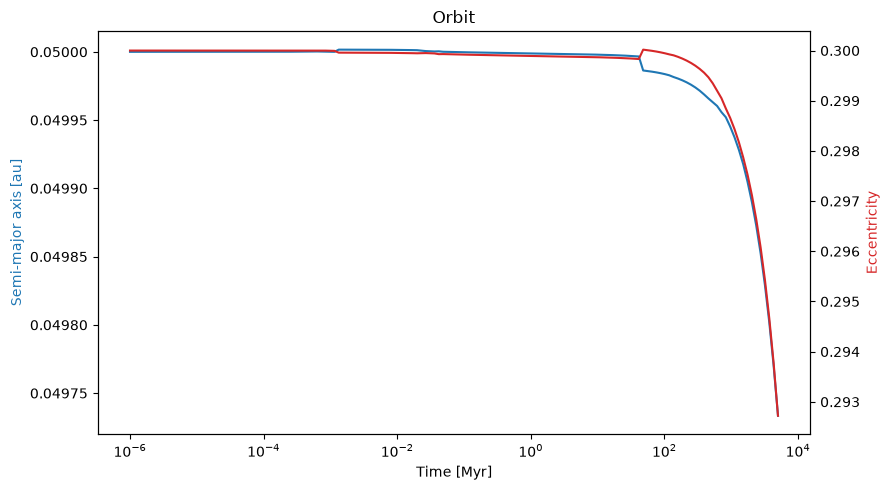

In [6]:
fig, ax_a = plt.subplots(figsize=(9, 5))
ax_e = ax_a.twinx()
ax_a.plot(time_myr[plotted], semi_major_axis[plotted] / au, color="tab:blue")
ax_e.plot(time_myr[plotted], eccentricity[plotted], color="tab:red")
ax_a.set_xscale("log")
ax_a.set_xlabel("Time [Myr]")
ax_a.set_ylabel("Semi-major axis [au]", color="tab:blue")
ax_e.set_ylabel("Eccentricity", color="tab:red")
ax_a.set_title("Orbit")
fig.tight_layout()
plt.show()

## Spin

The planet despins from 10 times its orbital motion within a few thousand years, passing every half-integer ratio until one holds it. With $e = 0.3$ the planet is first captured just below 2:1, at an equilibrium off the commensurability (a warm-mantle capture). Once melt appears near the surface, that equilibrium vanishes and the planet despins to 3:2, where its cold lid holds it exactly.

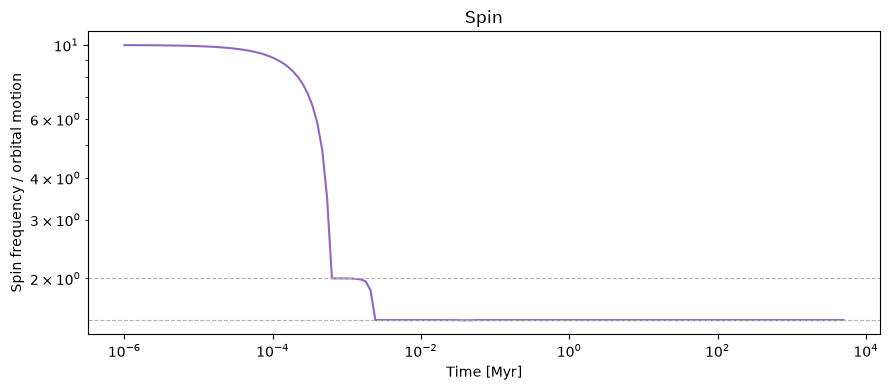

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_myr[plotted], history["spin_ratio"][plotted], color="tab:purple")
for ratio in (1.5, 2.0):
    ax.axhline(ratio, color="0.7", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"Spin frequency / orbital motion")
ax.set_title("Spin")
fig.tight_layout()
plt.show()

## Heating, Temperature, and Melt

Tidal heating dwarfs the radiogenic heat and warms the mantle by hundreds of kelvin within a few thousand years. Melt first forms where the conducting lid meets the adiabat, a few tens of km down, and grows into a molten band. The radial solver treats the band as a static liquid, which decouples the lid and cuts the tidal heating. The mantle then settles where the remaining heating is carried away by convection: a tidal-convective equilibrium.

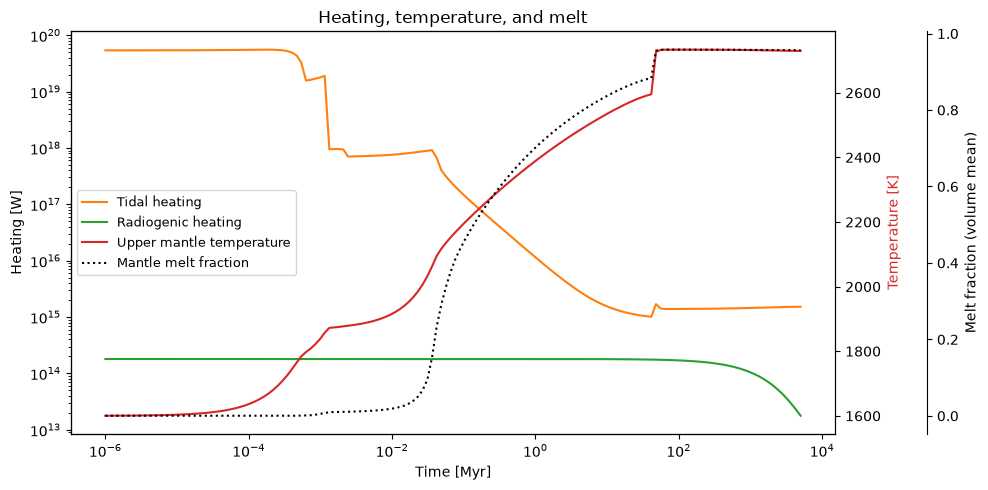

In [8]:
fig, ax_heat = plt.subplots(figsize=(10, 5))
ax_temperature = ax_heat.twinx()
ax_melt = ax_heat.twinx()
ax_melt.spines["right"].set_position(("axes", 1.12))

ax_heat.plot(time_myr[plotted], history["tidal"][plotted], color="tab:orange", label="Tidal heating")
ax_heat.plot(time_myr[plotted], history["radiogenic"][plotted], color="tab:green", label="Radiogenic heating")
ax_temperature.plot(time_myr[plotted], mantle_temperature[plotted], color="tab:red", label="Upper mantle temperature")
ax_melt.plot(time_myr[plotted], history["melt"][plotted], color="black", ls=":", label="Mantle melt fraction")

ax_heat.set_xscale("log")
ax_heat.set_yscale("log")
ax_heat.set_xlabel("Time [Myr]")
ax_heat.set_ylabel("Heating [W]")
ax_temperature.set_ylabel("Temperature [K]", color="tab:red")
ax_melt.set_ylabel("Melt fraction (volume mean)")
handles = [line for axis in (ax_heat, ax_temperature, ax_melt) for line in axis.get_lines()]
ax_heat.legend(handles, [line.get_label() for line in handles], loc="center left", fontsize=9)
ax_heat.set_title("Heating, temperature, and melt")
fig.tight_layout()
plt.show()

## Viscosity and Shear Modulus

The mantle's viscosity falls as it warms. Its shear modulus falls only where the mantle melts, by orders of magnitude once the melt fraction passes the critical value of the Henning model.

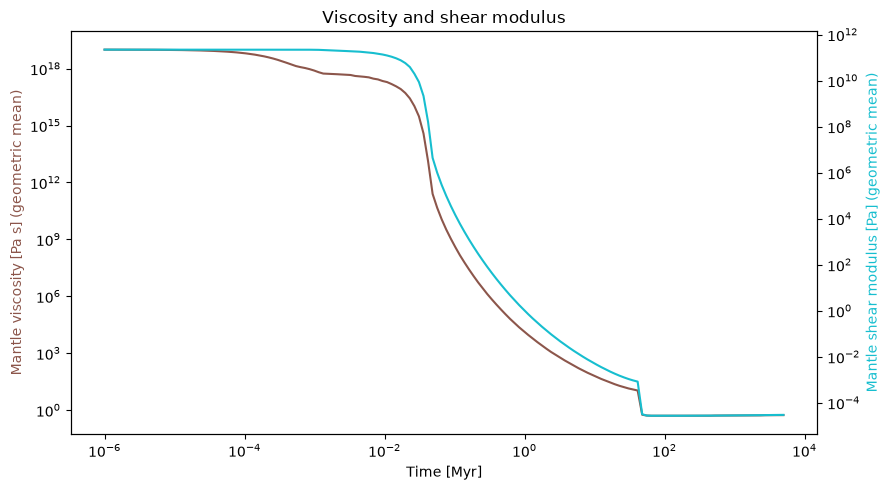

In [9]:
fig, ax_viscosity = plt.subplots(figsize=(9, 5))
ax_shear = ax_viscosity.twinx()
ax_viscosity.plot(time_myr[plotted], history["viscosity"][plotted], color="tab:brown")
ax_shear.plot(time_myr[plotted], history["shear"][plotted], color="tab:cyan")
ax_viscosity.set_xscale("log")
ax_viscosity.set_yscale("log")
ax_shear.set_yscale("log")
ax_viscosity.set_xlabel("Time [Myr]")
ax_viscosity.set_ylabel("Mantle viscosity [Pa s] (geometric mean)", color="tab:brown")
ax_shear.set_ylabel("Mantle shear modulus [Pa] (geometric mean)", color="tab:cyan")
ax_viscosity.set_title("Viscosity and shear modulus")
fig.tight_layout()
plt.show()

## Discussion

DISCUSSION_PLACEHOLDER

**References**

* Filippov, A. F. (1988). *Differential Equations with Discontinuous Righthand Sides*. Kluwer Academic Publishers.
* Henning, W. G., O'Connell, R. J., and Sasselov, D. D. (2009). Tidally heated terrestrial exoplanets: Viscoelastic response models. *The Astrophysical Journal*, 707(2), 1000-1015.
* Makarov, V. V., and Efroimsky, M. (2013). No pseudosynchronous rotation for terrestrial planets and moons. *The Astrophysical Journal*, 764(1), 27.
* Monteux, J., Andrault, D., and Samuel, H. (2016). On the cooling of a deep terrestrial magma ocean. *Earth and Planetary Science Letters*, 448, 140-149.